I'll study some features regarding energy blackouts for Edesur S.A.

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import wkb

In [ ]:
edn_cab_sub_geo = pd.read_csv(r"C:\Users\DELL\Desktop\Data\datasets\raws\datos_argentina\energia\edenor\distribucin-elctrica-edenor-at-cables-subterrneos.csv")

def cargar_wkb(x):
    try:
        return wkb.loads(bytes.fromhex(x))
    except Exception:
        return None

edn_cab_sub_geo["geometry"] = edn_cab_sub_geo["geom"].apply(cargar_wkb)

print("Geometrías inválidas:", edn_cab_sub_geo["geometry"].isna().sum())

edn_cab_sub_geo = gpd.GeoDataFrame(
    edn_cab_sub_geo,
    geometry="geometry",
    crs="EPSG:4326"
)


Geometrías inválidas: 8


In [17]:
geo_edn = gpd.read_file(r'C:\Users\DELL\Desktop\Data\datasets\processed\geo\concesion_edn.geojson')

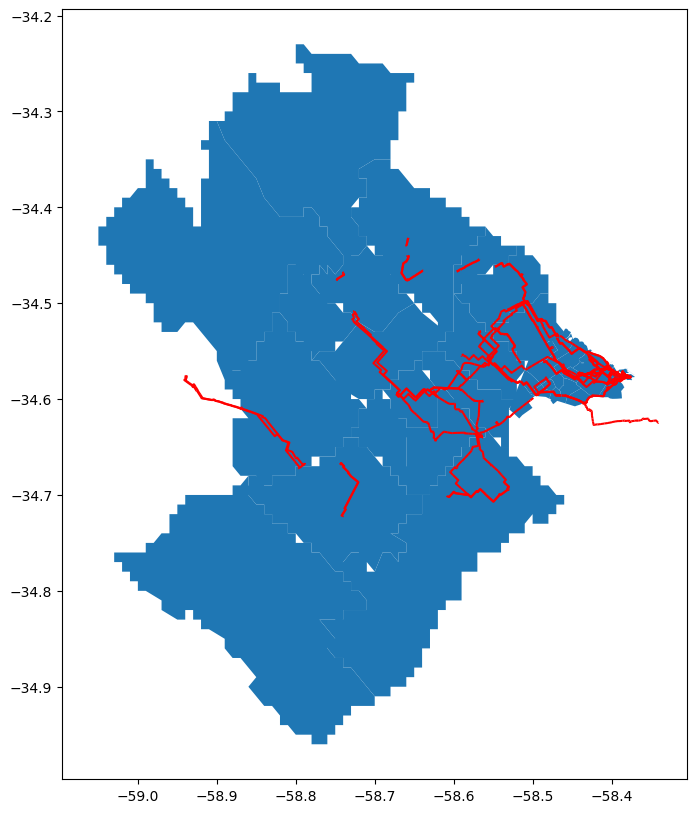

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))

geo_edn.plot(ax=ax)
edn_cab_sub_geo.plot(ax=ax,color='red')

plt.show()

In [20]:
edn_emp_mono_geo = pd.read_csv(r"C:\Users\DELL\Desktop\Data\datasets\raws\datos_argentina\energia\edenor\distribucin-elctrica-edenor-at-empalmes-monofsicos.csv")

edn_emp_mono_geo["geometry"] = edn_emp_mono_geo["geom"].apply(cargar_wkb)

print("Geometrías inválidas:", edn_emp_mono_geo["geometry"].isna().sum())

edn_emp_mono_geo = gpd.GeoDataFrame(
    edn_emp_mono_geo,
    geometry="geometry",
    crs="EPSG:4326"
)

Geometrías inválidas: 0


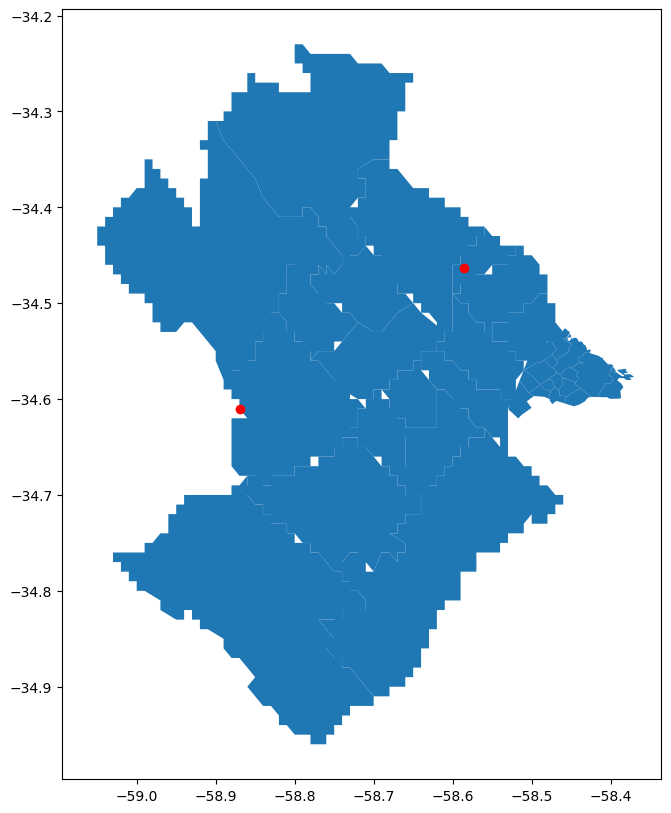

In [21]:
fig, ax = plt.subplots(figsize=(10,10))

geo_edn.plot(ax=ax)
edn_emp_mono_geo.plot(ax=ax,color='red')

plt.show()